# Comparando melhores resultados

Esse notebook compara os resultados ótimos calculados pelo algoritmo da força bruta (localizado no arquivo `best.csv`) e os resultados dos algoritmos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_melhores = pd.read_csv('best.csv', sep=';')

In [3]:
df_melhores.head()

,algorithm,filename,num_vertex,min_path,milisec,cost
0,BruteForce,data/FIS5-0.txt,5,"0,2,1,4,3",0.0,18430
1,BruteForce,data/FIS5-1.txt,5,"0,1,3,2,4",0.0,22351
2,BruteForce,data/FIS5-2.txt,5,"0,1,4,2,3",0.0,15356
3,BruteForce,data/FIS5-3.txt,5,"0,1,4,2,3",0.0,21245
4,BruteForce,data/FIS5-4.txt,5,"0,1,4,3,2",0.0,19418


In [4]:
df_execucoes = pd.read_csv('analysis_mean_min_max_std.csv', sep=',')

In [5]:
def is_smaller_instance(filename):
    # Extrai o número da instância do nome do arquivo
    num = int(filename.split('/')[-1].split('-')[0].replace('FIS', ''))
    return num <= 14

In [6]:
df_execucoes = df_execucoes[df_execucoes['filename'].apply(is_smaller_instance)]

In [7]:
df_execucoes.head()

,mean,std,min,max,milisec,filename,algorithm
0,18430.0,0.0,18430.0,18430.0,0.0,data/FIS5-0.txt,CheapestInsertion
1,22351.0,0.0,22351.0,22351.0,0.0,data/FIS5-1.txt,CheapestInsertion
2,15356.0,0.0,15356.0,15356.0,0.0,data/FIS5-2.txt,CheapestInsertion
3,21245.0,0.0,21245.0,21245.0,0.0,data/FIS5-3.txt,CheapestInsertion
4,19418.0,0.0,19418.0,19418.0,0.0,data/FIS5-4.txt,CheapestInsertion


In [8]:
n_instances = len(df_melhores)
algoritmos = df_execucoes['algorithm'].unique()
n_algo_execucoes = len(algoritmos)

assert n_algo_execucoes * n_instances == len(df_execucoes)

## Diferença entre a melhor solução e a encontrada

In [9]:
instancias = [f.split('data/FIS')[-1].replace('.txt', '') for f in df_melhores['filename'].unique()]
diferencas = {}
for algoritmo in algoritmos:
    diferencas[algoritmo] = {}

for i, exec in df_execucoes.iterrows():
    melhor_custo = df_melhores[df_melhores['filename'] == exec['filename']]['cost'].iloc[0]
    media_execucoes = exec['mean']
    diferencas[exec['algorithm']][exec['filename']] = media_execucoes - melhor_custo

In [10]:
translate = {
    'CheapestInsertion': 'Inserção mais barata',
    'NearestNeighborhood': 'Vizinho mais próximo',
    'GeneticImproved': 'Genético',
    'Memetic': 'Memético'
}

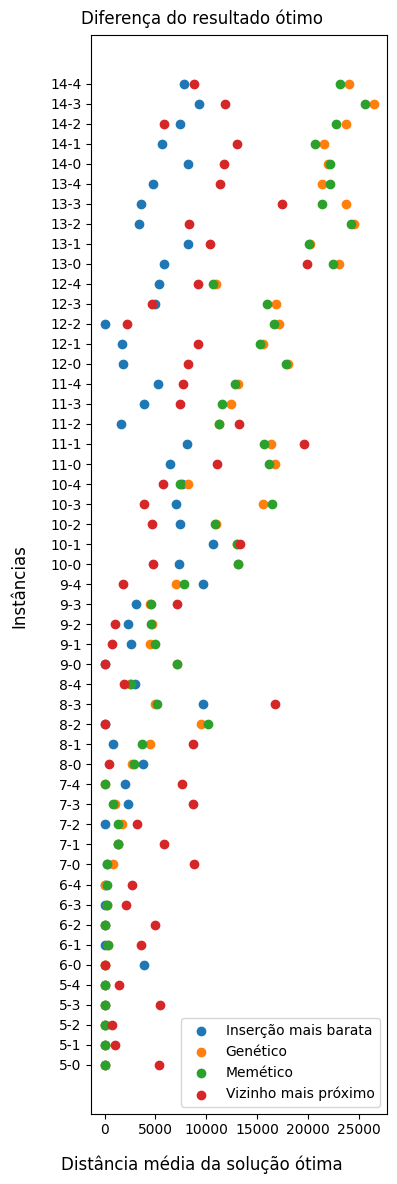

In [11]:
fig, ax = plt.subplots(figsize=(4, 12))

for algoritmo, execucoes in diferencas.items():
    ax.scatter(execucoes.values(), instancias, label=translate[algoritmo])

desired_labels = [str(i) for i in range(5, 15)]

desired_indices = [instancias.index(label + '-0') for label in desired_labels]
#ax.set_xticks(desired_indices)
#ax.set_xticklabels(desired_labels)

ax.legend()
fig.subplots_adjust(top=0.95)
fig.suptitle('Diferença do resultado ótimo')
fig.supxlabel('Distância média da solução ótima')
fig.supylabel('Instâncias')
fig.tight_layout()
plt.savefig('diferenca-resultado-otimo.png')

## Melhores execuções das maiores instâncias

In [12]:
df_execucoes = pd.read_csv('analysis_mean_min_max_std.csv', sep=',')

In [13]:
df_execucoes = df_execucoes[~df_execucoes['filename'].apply(is_smaller_instance)]

In [14]:
df_execucoes.head()

,mean,std,min,max,milisec,filename,algorithm
50,56446.0,0.0,56446.0,56446.0,3.23,data/FIS50-0.txt,CheapestInsertion
51,65375.0,0.0,65375.0,65375.0,3.00,data/FIS50-1.txt,CheapestInsertion
52,68485.0,0.0,68485.0,68485.0,3.00,data/FIS50-2.txt,CheapestInsertion
53,63566.0,0.0,63566.0,63566.0,3.00,data/FIS50-3.txt,CheapestInsertion
54,72587.0,0.0,72587.0,72587.0,3.03,data/FIS50-4.txt,CheapestInsertion


In [15]:
instancias = df_execucoes['filename'].unique()
instancias

array(['data/FIS50-0.txt', 'data/FIS50-1.txt', 'data/FIS50-2.txt',
       'data/FIS50-3.txt', 'data/FIS50-4.txt', 'data/FIS75-0.txt',
       'data/FIS75-1.txt', 'data/FIS75-2.txt', 'data/FIS75-3.txt',
       'data/FIS75-4.txt', 'data/FIS100-0.txt', 'data/FIS100-1.txt',
       'data/FIS100-2.txt', 'data/FIS100-3.txt', 'data/FIS100-4.txt'],
      dtype=object)

In [16]:
melhores = []
diferencas = {}

for algoritmo in algoritmos:
    diferencas[algoritmo] = {}

for instancia in instancias:
    df_exec_instancia = df_execucoes[df_execucoes['filename'] == instancia]

    melhor_media = df_exec_instancia['mean'].min()
    melhores.append(melhor_media)
    for i, exec in df_exec_instancia.iterrows():
        diferencas[exec['algorithm']][instancia] = exec['mean'] - melhor_media

In [17]:
instancias = [f.split('data/FIS')[-1].replace('.txt', '') for f in df_execucoes['filename'].unique()]

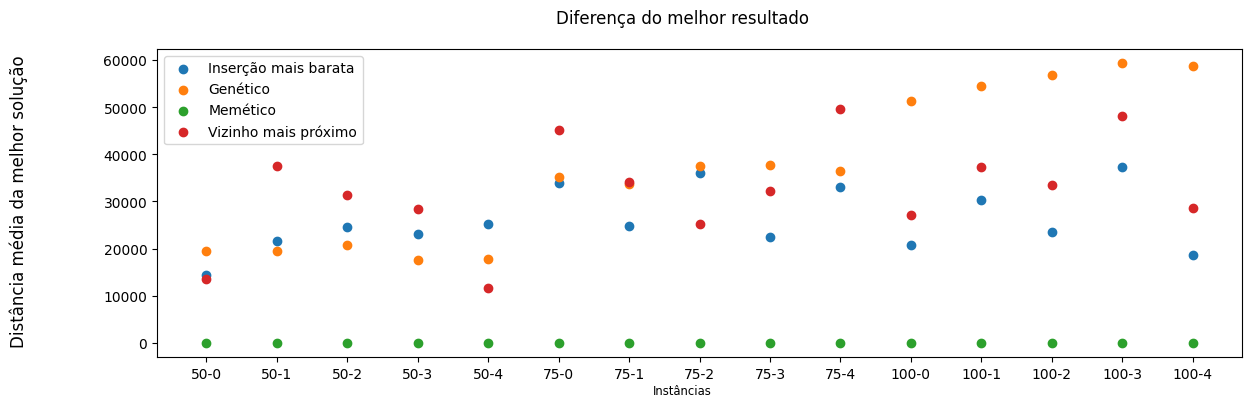

In [18]:
fig, ax = plt.subplots(figsize=(14, 4))

for algoritmo, execucoes in diferencas.items():
    ax.scatter(instancias, execucoes.values(), label=translate[algoritmo])

ax.legend()
fig.suptitle('Diferença do melhor resultado')
fig.supylabel('Distância média da melhor solução')
fig.supxlabel('Instâncias', fontsize='small')
plt.savefig('diferenca-melhor-resultado.png')

## Tempo de execução Memetic vs Genetic 

In [19]:
df = pd.read_csv('2023-08-20.csv', sep=';')

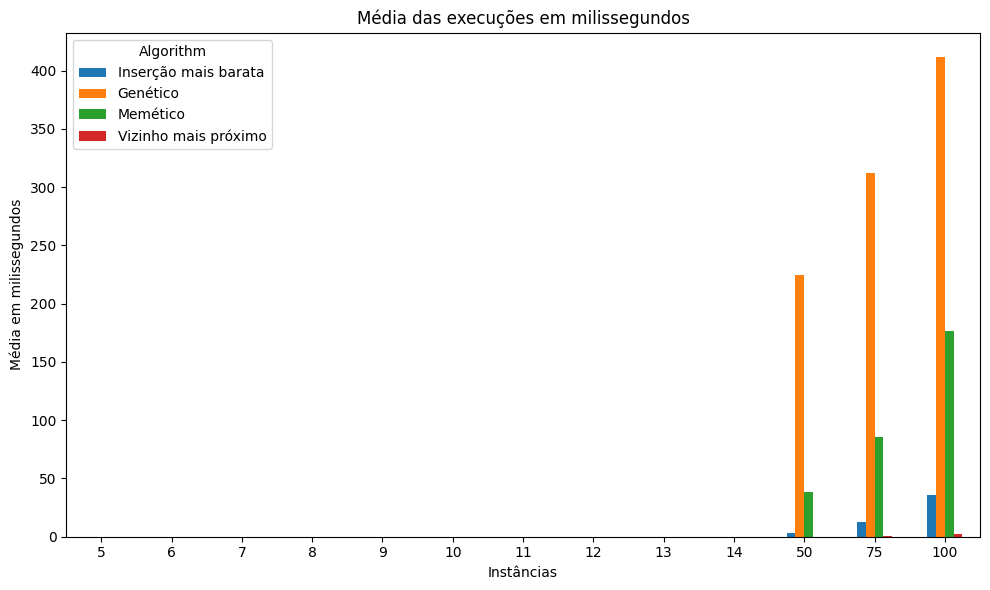

In [20]:
# Extracting 'i' from filename and sorting
df['i'] = df['filename'].str.extract('FIS(\d+)-')[0].astype(int)

# Grouping by filename and algorithm and calculating the average milliseconds
grouped = df.groupby(['i', 'algorithm'])['milisec'].mean().unstack()
grouped.columns = [translate[col] for col in grouped.columns]

# Plotting the results
grouped.plot(kind='bar', figsize=(10, 6))
plt.title('Média das execuções em milissegundos')
plt.ylabel('Média em milissegundos')
plt.xlabel('Instâncias')
plt.xticks(ticks=range(len(grouped.index)), labels=grouped.index, rotation=0)
plt.legend(title='Algorithm')
plt.tight_layout()
plt.savefig('media-execucao-milissegundos.png')